# Interpretabilidade — Predição de Alfabetização

## Quais Variáveis Explicam o Resultado

**Objetivo:** Identificar quais variáveis influenciam a predição e em que direção, traduzindo o modelo em inteligência aplicável à decisão de política pública.

**O que este notebook NÃO faz:**
- Treinamento do modelo principal (a pipeline é carregada de `models/`, treinada em `02_modelagem.ipynb`)
- Alteração de features ou hiperparâmetros
- Afirmações causais: o modelo mede associação, não causa

**O que este notebook entrega:**
1. Importância por permutação, medida sobre o conjunto de teste
2. Importância e direção de efeito por valores SHAP
3. Controle negativo validando a leitura da importância
4. Teste das três hipóteses formuladas na análise exploratória
5. Municípios com maior risco previsto, respondendo à pergunta de negócio

## 1. Setup e Carga do Modelo

A divisão treino e teste é reconstruída com a mesma semente usada na modelagem, o que reproduz exatamente a mesma partição. O modelo nunca viu os municípios do conjunto de teste.

In [17]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit

CAMINHO_BASE = "../data/base_gold_alunos.parquet"
CAMINHO_MODELO = "../models/pipeline_alfabetizacao.joblib"
CAMINHO_IMAGENS = "../images"
ANO_MODELAGEM = 2024
SEMENTE = 42
AMOSTRA_SHAP = 20_000
AMOSTRA_PERMUTACAO = 100_000
MINIMO_ALUNOS = 100

ALVO = "alfabetizado"
AGRUPADOR = "id_municipio"

FEATURES_NUMERICAS = [
    "taxa_alfabetizacao_escola_historica",
    "alunos_avaliados_escola_historica",
    "taxa_alfabetizacao_municipio_historica",
    "idhm",
    "indice_gini",
    "taxa_criancas_dom_sem_fund",
    "taxa_atraso_0_fundamental",
    "diferenca_escola_municipio",
]
FEATURES_CATEGORICAS = ["sigla_uf", "rede_nome"]

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [18]:
base = pd.read_parquet(CAMINHO_BASE)

universo = base[
    (base["presenca"] == 1)
    & (base["preenchimento_caderno"] == 1)
    & (base["ano"] == ANO_MODELAGEM)
].copy()

universo["diferenca_escola_municipio"] = (
    universo["taxa_alfabetizacao_escola_historica"]
    - universo["taxa_alfabetizacao_municipio_historica"]
)

X = universo[FEATURES_NUMERICAS + FEATURES_CATEGORICAS]
y = universo[ALVO]
grupos = universo[AGRUPADOR]

divisor = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMENTE)
indices_treino, indices_teste = next(divisor.split(X, y, groups=grupos))

X_treino, y_treino = X.iloc[indices_treino], y.iloc[indices_treino]
X_teste, y_teste = X.iloc[indices_teste], y.iloc[indices_teste]
municipios_teste = universo.iloc[indices_teste]

modelo = joblib.load(CAMINHO_MODELO)

print("=" * 60)
print("  MODELO E CONJUNTO DE TESTE")
print("=" * 60)
print(f"\nRegistros no teste: {len(X_teste):>10,}")
print(f"Municípios:         {municipios_teste[AGRUPADOR].nunique():>10,}")
print(f"\nModelo: {type(modelo.named_steps['modelo']).__name__}")

  MODELO E CONJUNTO DE TESTE

Registros no teste:    330,836
Municípios:              1,104

Modelo: HistGradientBoostingClassifier


## 2. Importância por Permutação

A importância por permutação embaralha uma variável de cada vez e mede quanto o desempenho cai. É calculada sobre o conjunto de teste, de modo que reflete contribuição para a generalização, não para o ajuste.

A medida usa uma amostra de 100 mil registros: com 330 mil, cada repetição exigiria nova predição sobre a base inteira.

In [ ]:
amostra_permutacao = X_teste.sample(AMOSTRA_PERMUTACAO, random_state=SEMENTE)

importancia = permutation_importance(
    modelo,
    amostra_permutacao,
    y_teste.loc[amostra_permutacao.index],
    scoring="roc_auc",
    n_repeats=5,
    random_state=SEMENTE,
    n_jobs=2,
)

ranking = (
    pd.DataFrame(
        {
            "variavel": amostra_permutacao.columns,
            "queda_media": importancia.importances_mean,
            "desvio": importancia.importances_std,
        }
    )
    .sort_values("queda_media", ascending=False)
    .reset_index(drop=True)
)

print("=" * 60)
print("  QUEDA DE ROC-AUC AO EMBARALHAR CADA VARIÁVEL")
print("=" * 60)
print()
print(ranking.round(5).to_string(index=False))

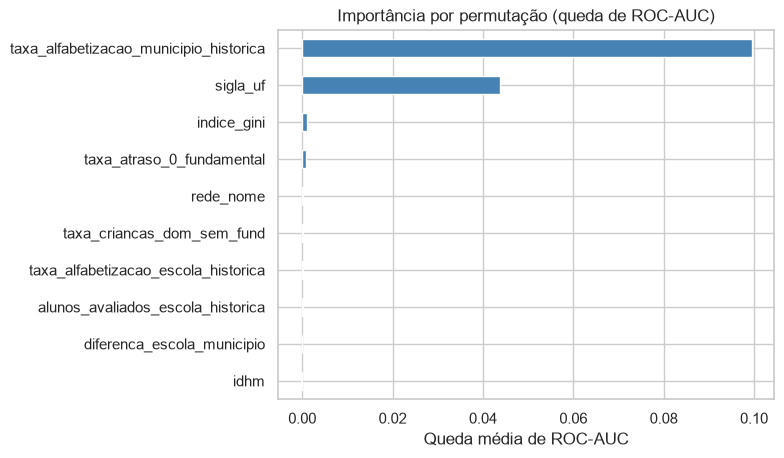

In [ ]:
ordenado = ranking.sort_values("queda_media")

eixo = ordenado.set_index("variavel")["queda_media"].plot(
    kind="barh", xerr=ordenado["desvio"], color="steelblue"
)
eixo.set_title("Importância por permutação (queda de ROC-AUC)")
eixo.set_xlabel("Queda média de ROC-AUC")
eixo.set_ylabel("")
plt.savefig(f"{CAMINHO_IMAGENS}/importancia_permutacao.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Valores SHAP

A importância por permutação diz quanto cada variável contribui no agregado. O SHAP vai além: atribui a cada predição individual a contribuição de cada variável, revelando também a direção do efeito e como ele varia ao longo da faixa de valores.

O cálculo roda sobre a matriz já transformada pelo pré-processamento, e os nomes das colunas vêm do próprio `ColumnTransformer` para que as categorias codificadas fiquem identificadas.

In [ ]:
preprocessador = modelo.named_steps["preprocessamento"]
estimador = modelo.named_steps["modelo"]

amostra_shap = X_teste.sample(AMOSTRA_SHAP, random_state=SEMENTE)
matriz = pd.DataFrame(
    preprocessador.transform(amostra_shap),
    columns=preprocessador.get_feature_names_out(),
    index=amostra_shap.index,
)

explicador = shap.Explainer(estimador, matriz)
valores_shap = explicador(matriz)

print(f"Valores SHAP calculados para {matriz.shape[0]:,} registros e {matriz.shape[1]} colunas")

Background dataset has 20000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=20000 when initializing the masker.
 99%|===================| 19833/20000 [00:55<00:00]        

Valores SHAP calculados para 20,000 registros e 37 colunas


### Importância global

A média do valor absoluto do SHAP mede quanto cada variável desloca a predição, independentemente da direção.

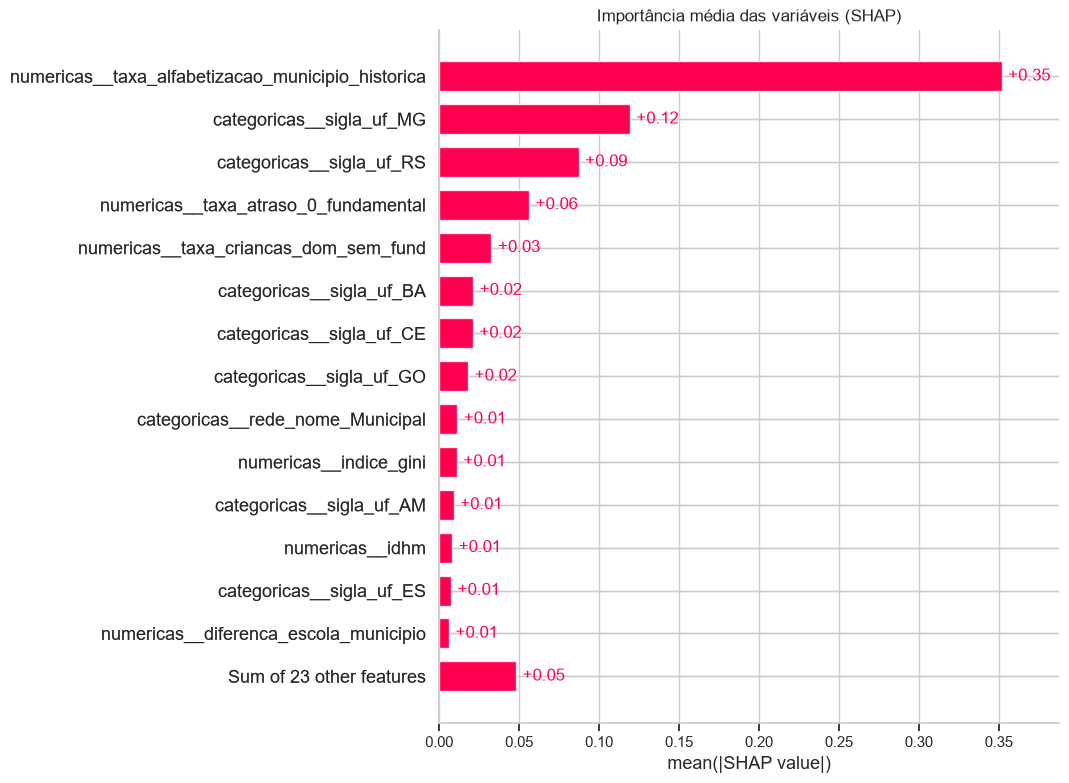

In [ ]:
shap.plots.bar(valores_shap, max_display=15, show=False)
plt.title("Importância média das variáveis (SHAP)")
plt.savefig(f"{CAMINHO_IMAGENS}/shap_importancia.png", dpi=150, bbox_inches="tight")
plt.show()

### Direção do efeito

Cada ponto é um aluno. A posição horizontal indica quanto a variável empurrou a predição, e a cor indica se o valor da variável era alto ou baixo naquele registro.

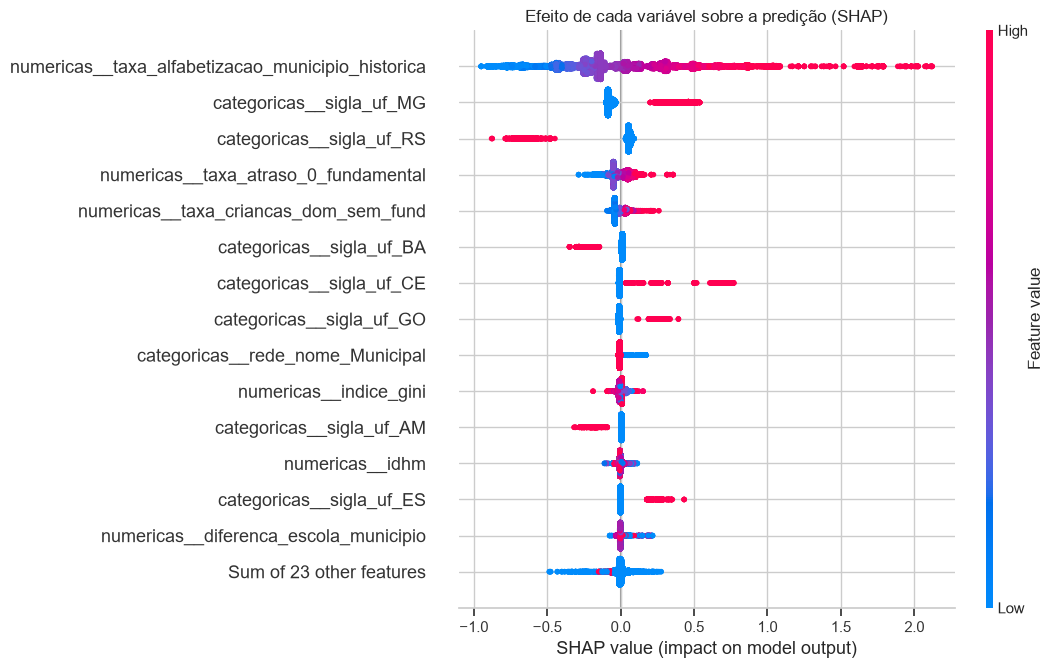

In [ ]:
shap.plots.beeswarm(valores_shap, max_display=15, show=False)
plt.title("Efeito de cada variável sobre a predição (SHAP)")
plt.savefig(f"{CAMINHO_IMAGENS}/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

### Comportamento ao longo da faixa de valores

O gráfico de dependência mostra a relação entre o valor da variável e sua contribuição. Relações em degrau aparecem como saltos, e não como linhas.

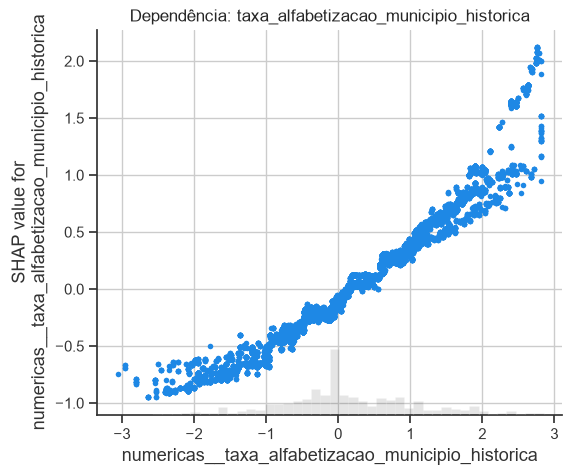

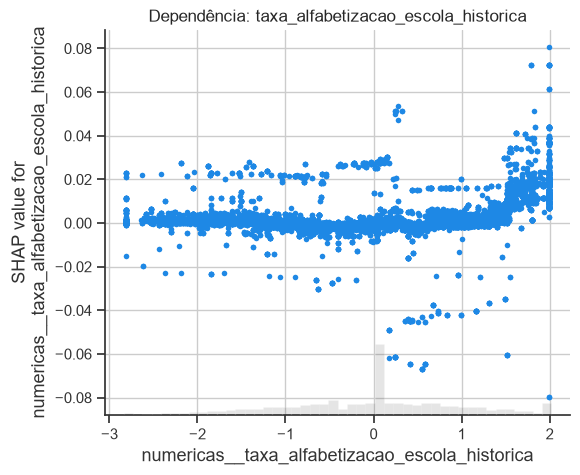

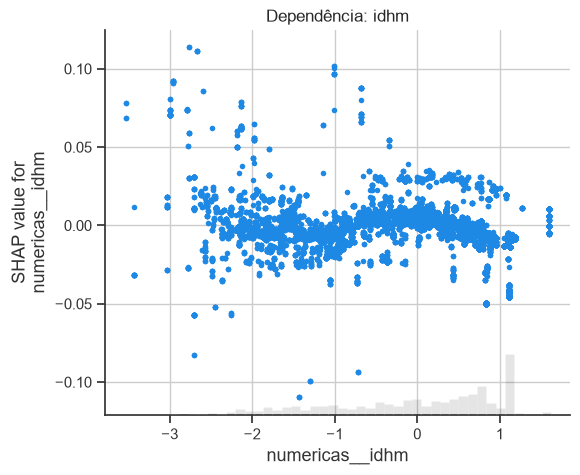

In [ ]:
PRINCIPAIS = [
    "numericas__taxa_alfabetizacao_municipio_historica",
    "numericas__taxa_alfabetizacao_escola_historica",
    "numericas__idhm",
]

for coluna in PRINCIPAIS:
    nome = coluna.split("__")[-1]
    shap.plots.scatter(valores_shap[:, coluna], show=False)
    plt.title(f"Dependência: {nome}")
    plt.savefig(f"{CAMINHO_IMAGENS}/shap_dependencia_{nome}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 4. Controle Negativo

Uma variável sem relação com o alvo deve receber importância próxima de zero. Se aparecer entre as relevantes, a leitura do ranking não é confiável.

O teste substitui os valores de `indice_gini` por ruído aleatório, mantendo o mesmo conjunto de colunas, treina um modelo de controle sobre o conjunto de treino e mede a importância por permutação no teste. O modelo principal permanece intacto.

A escolha da coluna não é arbitrária: `indice_gini` é a de menor correlação com o alvo (-0,05) entre as mantidas. Se o ruído ficar no fim do ranking, a leitura está validada; se a posição da variável não mudar em relação ao modelo original, o teste também revela que ela nunca carregou informação.

In [ ]:
gerador = np.random.default_rng(SEMENTE)

X_treino_controle = X_treino.assign(indice_gini=gerador.normal(size=len(X_treino)))
X_teste_controle = X_teste.assign(indice_gini=gerador.normal(size=len(X_teste)))

modelo_controle = clone(modelo).fit(X_treino_controle, y_treino)

amostra_controle = X_teste_controle.sample(50_000, random_state=SEMENTE)

importancia_controle = permutation_importance(
    modelo_controle,
    amostra_controle,
    y_teste.loc[amostra_controle.index],
    scoring="roc_auc",
    n_repeats=3,
    random_state=SEMENTE,
    n_jobs=2,
)

controle = (
    pd.DataFrame({
        "variavel": X_teste_controle.columns,
        "queda_media": importancia_controle.importances_mean,
    })
    .sort_values("queda_media", ascending=False)
    .reset_index(drop=True)
)

print("=" * 60)
print("  RANKING COM indice_gini SUBSTITUÍDO POR RUÍDO")
print("=" * 60)
print()
print(controle.round(5).to_string(index=False))
print(f"\nPosição do ruído: {controle.index[controle['variavel'] == 'indice_gini'][0] + 1} de {len(controle)}")

  RANKING COM indice_gini SUBSTITUÍDO POR RUÍDO

                              variavel  queda_media
taxa_alfabetizacao_municipio_historica      0.09883
                              sigla_uf      0.04619
             taxa_atraso_0_fundamental      0.00197
                             rede_nome      0.00044
            diferenca_escola_municipio      0.00020
     alunos_avaliados_escola_historica      0.00001
                           indice_gini     -0.00000
   taxa_alfabetizacao_escola_historica     -0.00005
                                  idhm     -0.00022
            taxa_criancas_dom_sem_fund     -0.00056

Posição do ruído: 7 de 10


## 5. Teste das Hipóteses

As três hipóteses foram formuladas na análise exploratória, antes do treinamento.

In [ ]:
importancia_media = pd.Series(np.abs(valores_shap.values).mean(axis=0), index=matriz.columns)


def importancia_de(sufixos: list[str]) -> float:
    selecionadas = [c for c in importancia_media.index if any(c.endswith(s) for s in sufixos)]
    return importancia_media[selecionadas].sum()


EDUCACIONAIS = [
    "taxa_alfabetizacao_escola_historica",
    "taxa_alfabetizacao_municipio_historica",
    "diferenca_escola_municipio",
    "alunos_avaliados_escola_historica",
]
SOCIOECONOMICAS = ["idhm", "indice_gini", "taxa_criancas_dom_sem_fund"]

print("=" * 60)
print("  H1: HISTÓRICO EDUCACIONAL SUPERA O SOCIOECONÔMICO")
print("=" * 60)
print(f"\nImportância somada — educacionais:    {importancia_de(EDUCACIONAIS):.5f}")
print(f"Importância somada — socioeconômicas: {importancia_de(SOCIOECONOMICAS):.5f}")

  H1: HISTÓRICO EDUCACIONAL SUPERA O SOCIOECONÔMICO

Importância somada — educacionais:    0.36256
Importância somada — socioeconômicas: 0.05166


In [ ]:
print("=" * 60)
print("  H2: DEFASAGEM DO ATLAS LIMITA O PODER PREDITIVO")
print("=" * 60)
print(f"\nIndicadores socioeconômicos de 2010: {importancia_de(SOCIOECONOMICAS):.5f}")
print(f"Indicador educacional de 2010:       {importancia_de(['taxa_atraso_0_fundamental']):.5f}")

  H2: DEFASAGEM DO ATLAS LIMITA O PODER PREDITIVO

Indicadores socioeconômicos de 2010: 0.05166
Indicador educacional de 2010:       0.05615


In [ ]:
coluna_tamanho = "numericas__alunos_avaliados_escola_historica"
coluna_escola = "numericas__taxa_alfabetizacao_escola_historica"

pequenas = (matriz[coluna_tamanho] <= matriz[coluna_tamanho].median()).values
shap_escola = np.abs(valores_shap.values[:, matriz.columns.get_loc(coluna_escola)])

print("=" * 60)
print("  H3: CONFIABILIDADE DA TAXA ESCOLAR MODERA SEU EFEITO")
print("=" * 60)
print(f"\nSHAP médio da taxa escolar em escolas pequenas: {shap_escola[pequenas].mean():.5f}")
print(f"SHAP médio da taxa escolar em escolas grandes:  {shap_escola[~pequenas].mean():.5f}")

  H3: CONFIABILIDADE DA TAXA ESCOLAR MODERA SEU EFEITO

SHAP médio da taxa escolar em escolas pequenas: 0.00332
SHAP médio da taxa escolar em escolas grandes:  0.00264


## 6. Municípios com Maior Risco Previsto

A análise exploratória identificou municípios pelo resultado já observado. O modelo acrescenta algo diferente: uma estimativa de risco aplicável onde ainda não há medição.

O recorte exige um mínimo de alunos, já que em municípios muito pequenos a média oscila por acaso.

In [ ]:
municipios_teste = municipios_teste.assign(probabilidade=modelo.predict_proba(X_teste)[:, 1])

agregado = (
    municipios_teste.groupby(["nome_municipio", "sigla_uf"], observed=True)
    .agg(
        probabilidade_media=("probabilidade", "mean"),
        taxa_observada=("alfabetizado", "mean"),
        alunos=("alfabetizado", "size"),
    )
    .query("alunos >= @MINIMO_ALUNOS")
)

print("=" * 60)
print(f"  15 MUNICÍPIOS COM MAIOR RISCO PREVISTO (mínimo {MINIMO_ALUNOS} alunos)")
print("=" * 60)
print()
print(agregado.nsmallest(15, "probabilidade_media").round(3).to_string())

  15 MUNICÍPIOS COM MAIOR RISCO PREVISTO (mínimo 100 alunos)

                                  probabilidade_media  taxa_observada  alunos
nome_municipio          sigla_uf                                             
Formosa do Rio Preto    BA                      0.285           0.282     234
Senhor do Bonfim        BA                      0.289           0.240     487
Canudos                 BA                      0.289           0.301     156
Paratinga               BA                      0.291           0.245     233
Jussara                 BA                      0.297           0.434     122
Santaluz                BA                      0.298           0.291     199
Pilão Arcado            BA                      0.301           0.225     391
São Francisco do Conde  BA                      0.303           0.257     342
Ubatã                   BA                      0.305           0.419     105
Buerarema               BA                      0.306           0.286     140
Ca

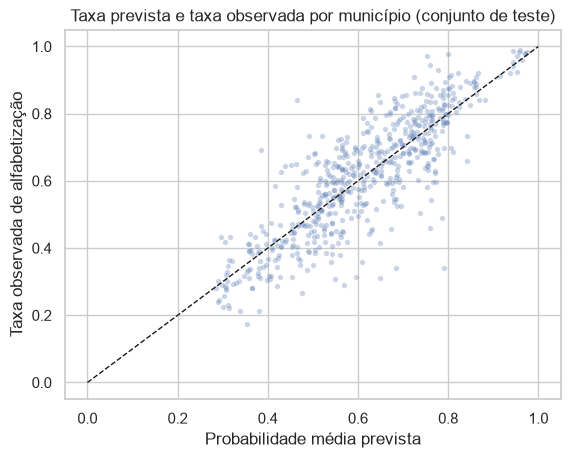

Correlação entre previsto e observado no grão município: 0.8449


In [ ]:
eixo = sns.scatterplot(data=agregado, x="probabilidade_media", y="taxa_observada", alpha=0.3, s=15)
eixo.plot([0, 1], [0, 1], "k--", linewidth=1)
eixo.set_title("Taxa prevista e taxa observada por município (conjunto de teste)")
eixo.set_xlabel("Probabilidade média prevista")
eixo.set_ylabel("Taxa observada de alfabetização")
plt.savefig(f"{CAMINHO_IMAGENS}/previsto_vs_observado.png", dpi=150, bbox_inches="tight")
plt.show()

correlacao = agregado["probabilidade_media"].corr(agregado["taxa_observada"])
print(f"Correlação entre previsto e observado no grão município: {correlacao:.4f}")

## 7. Conclusões da Interpretabilidade

| Pergunta | Resposta |
|---|---|
| Quais fatores mais impactam a alfabetização? | O histórico de alfabetização do município (queda de 0,0995 no ROC-AUC) e a unidade federativa (0,0437). As demais oito variáveis são indistinguíveis de ruído |
| H1 confirmada? | Sim. Importância SHAP somada de 0,363 para as educacionais contra 0,052 para as socioeconômicas, razão de 7 para 1 |
| H2 confirmada? | Não. O indicador educacional de 2010 (0,056) supera todas as socioeconômicas de 2010 somadas (0,052). A defasagem não é o fator limitante |
| H3 confirmada? | Não, e na direção oposta. SHAP de 0,0033 em escolas pequenas contra 0,0026 nas grandes, ambos irrelevantes |
| O controle negativo validou a leitura? | Sim. O ruído ficou em 7º de 10, com queda de -0,00000, estabelecendo o patamar abaixo do qual a importância é indistinguível de aleatório |
| Quais municípios apresentam maior risco? | Os quinze de maior risco previsto estão todos na Bahia, com probabilidade média entre 0,285 e 0,310 |
| Desempenho no grão município | Correlação de 0,8449 entre taxa prevista e observada |

### O modelo usa duas variáveis

A importância por permutação concentra praticamente todo o desempenho em `taxa_alfabetizacao_municipio_historica` e `sigla_uf`. O controle negativo fornece a régua para afirmar isso: com o ruído medindo -0,00000, qualquer variável abaixo de aproximadamente 0,001 é estatisticamente indistinguível de aleatório. Isso inclui o IDHM, a taxa histórica da escola e o atributo derivado.

No SHAP a unidade federativa aparece fragmentada em 27 colunas. Somadas, alcançam cerca de 0,30, contra 0,35 do histórico municipal: as duas variáveis dominantes têm peso comparável, e o modelo é essencialmente uma combinação entre o desempenho passado do município e o estado a que ele pertence.

### SHAP e permutação medem coisas diferentes

As duas medidas discordam em `taxa_atraso_0_fundamental`: SHAP de 0,056 contra queda de 0,0009 na permutação. A divergência é esperada e informativa.

O SHAP mede quanto a variável desloca a saída do modelo. A permutação mede quanto o desempenho cai quando ela é embaralhada. Uma variável redundante desloca a saída, mas não faz falta ao ser removida, porque as correlacionadas compensam a perda. `taxa_atraso_0_fundamental` correlaciona 0,70 com o IDHM e 0,32 com a taxa histórica municipal.

A leitura conjunta é que o modelo usa essas variáveis, mas não depende delas.

### Efeitos estaduais divergem do que a renda preveria

O gráfico de dispersão dos valores SHAP mostra dois estados em direções opostas, ambos após o modelo já ter considerado o histórico do município e os indicadores socioeconômicos.

O Ceará empurra a predição para alfabetizado, com contribuições entre 0,3 e 0,8. Minas Gerais apresenta efeito positivo semelhante. O Rio Grande do Sul apresenta o efeito negativo mais forte do conjunto, próximo de -0,8, apesar de figurar entre as unidades federativas de maior IDHM.

O resultado do Rio Grande do Sul é registrado como achado a investigar, não como conclusão: pode refletir desempenho real na avaliação, diferenças de participação ou composição da amostra de municípios sorteados para o conjunto de teste.

### Convergência com a análise exploratória

O agrupamento de municípios havia mostrado dois grupos com perfil socioeconômico idêntico e 28 pontos percentuais de diferença na alfabetização. A interpretabilidade chega ao mesmo lugar por outro caminho: o IDHM é ruído no modelo, as socioeconômicas valem um sétimo das educacionais, e o efeito estadual pesa tanto quanto o histórico municipal.

Condição socioeconômica não determina o resultado educacional. A diferença está em fatores que a base não mede diretamente e que pertencem à esfera da gestão educacional, que é onde a política pública atua.